In [ ]:
!pip install -U transformers accelerate datasets scikit-learn pandas matplotlib


In [ ]:
import os
import pickle
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_fscore_support

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML_Models/emotion_model_v2"
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
emotion_cols = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]


In [ ]:
dataset = load_dataset("go_emotions")


In [ ]:
df = dataset["train"].to_pandas().sample(
    n=12000,
    random_state=42
).reset_index(drop=True)


In [ ]:
label_names = dataset["train"].features["labels"].feature.names
print(label_names)


In [ ]:
df["label_names"] = df["labels"].apply(
    lambda ids: [label_names[i] for i in ids]
)

df = df[df["label_names"].map(len) > 0].reset_index(drop=True)


In [ ]:
mlb = MultiLabelBinarizer(classes=label_names)
Y = mlb.fit_transform(df["label_names"])

with open(f"{MODEL_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(mlb, f)


In [ ]:
label_counts = Y.sum(axis=0)
label_counts = torch.tensor(label_counts, dtype=torch.float)

print("How often each emotion appears:")
for name, count in zip(label_names, label_counts):
    print(f"{name:15s}: {int(count)}")


In [ ]:
class_weights = 1.0 / (label_counts + 1e-6)
class_weights = class_weights / class_weights.mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

print("\nImportance given to each emotion:")
for name, weight in zip(label_names, class_weights):
    print(f"{name:15s}: {weight.item():.2f}")


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

encodings = tokenizer(
    df["text"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)


In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }


In [ ]:
full_dataset = EmotionDataset(encodings, Y)

indices = np.arange(len(full_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=42
)

train_ds = torch.utils.data.Subset(full_dataset, train_idx)
val_ds   = torch.utils.data.Subset(full_dataset, val_idx)

print("Train:", len(train_ds))
print("Val:", len(val_ds))


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names),
    problem_type="multi_label_classification"
)


In [ ]:
param_dtype = next(model.parameters()).dtype
class_weights = class_weights.to(dtype=param_dtype, device=device)

class WeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = torch.nn.BCEWithLogitsLoss(
            pos_weight=class_weights
        )

        loss = loss_function(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.25).astype(int)

    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )

    macro_f1 = f1_score(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "precision_micro": micro_p,
        "recall_micro": micro_r
    }


In [ ]:
training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    report_to="none",
)


In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


In [ ]:
def predict(text, top_k=8):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(model.device)

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.sigmoid(logits)[0].cpu().numpy()
    order = probs.argsort()[::-1]

    best_emotion = (
        label_names[order[0]],
        round(float(probs[order[0]]), 4)
    )

    emotion_probabilities = [
        (label_names[i], round(float(probs[i]), 4))
        for i in order[:top_k]
        if probs[i] > 0.01
    ]

    return {
        "best_emotion": best_emotion,
        "emotion_probabilities": emotion_probabilities
    }


In [ ]:
tests = [
    "I'm broken and sad",
    "I'm proud and excited",
    "I love you but I'm scared",
    "This is hilarious",
    "Everything goes wrong"
]

for t in tests:
    print(t)
    print(predict(t))
    print("-" * 40)


In [ ]:
# Save the best trained model
trainer.save_model(MODEL_DIR)


In [ ]:
tokenizer.save_pretrained(MODEL_DIR)


In [ ]:
with open(f"{MODEL_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(mlb, f)


In [ ]:
import os

print("Saved files:")
for file in os.listdir(MODEL_DIR):
    print(file)


In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/ML_Models/emotion_model_v2"

if os.path.exists(MODEL_DIR):
    print("✅ Model directory exists\n")
    print("📂 Files inside MODEL_DIR:\n")

    for file in os.listdir(MODEL_DIR):
        print(" -", file)
else:
    print("❌ Model directory does NOT exist")


In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import pickle

MODEL_DIR = "/content/drive/MyDrive/ML_Models/psysense-emotion-ai"

# Load model
model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

# Load label encoder
with open(f"{MODEL_DIR}/label_encoder.pkl", "rb") as f:
    mlb = pickle.load(f)

print("✅ Model, tokenizer, and label encoder loaded successfully!")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch
import pickle
import numpy as np
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast
)

# Path where model is saved
MODEL_DIR = "/content/drive/MyDrive/ML_Models/psysense-emotion-ai"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

# Load label encoder
with open(f"{MODEL_DIR}/label_encoder.pkl", "rb") as f:
    mlb = pickle.load(f)

# Emotion labels
label_names = mlb.classes_

print("✅ Model, tokenizer, and labels loaded")


In [ ]:
def predict_emotions(text, threshold=0.25, top_k=8):
    """
    Predict emotions for a given text.
    Returns structured output (industry-friendly).
    """

    # Safety check
    if not text or not text.strip():
        return {"error": "Empty input text"}

    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(**inputs).logits

    # Convert logits → probabilities
    probs = torch.sigmoid(logits)[0].cpu().numpy()

    # Sort by confidence
    sorted_idx = probs.argsort()[::-1]

    # Dominant emotion
    dominant_emotion = {
        "label": label_names[sorted_idx[0]],
        "confidence": round(float(probs[sorted_idx[0]]), 4)
    }

    # Active emotions (above threshold)
    active_emotions = [
        {
            "label": label_names[i],
            "confidence": round(float(probs[i]), 4)
        }
        for i in sorted_idx
        if probs[i] >= threshold
    ]

    # Top-k (transparent view)
    top_emotions = [
        (label_names[i], round(float(probs[i]), 4))
        for i in sorted_idx[:top_k]
    ]

    return {
        "input_text": text,
        "dominant_emotion": dominant_emotion,
        "active_emotions": active_emotions,
        "top_emotions": top_emotions
    }


In [ ]:
tests = [
    "I'm broken and sad",
    "I'm proud and excited",
    "I love you but I'm scared",
    "This is hilarious",
    "Everything goes wrong",
    "ok",
    "🙂"
]

for t in tests:
    result = predict_emotions(t)
    print(result)
    print("-" * 50)


{'input_text': "I'm broken and sad", 'dominant_emotion': {'label': 'sadness', 'confidence': 0.7448}, 'active_emotions': [{'label': 'sadness', 'confidence': 0.7448}], 'top_emotions': [('sadness', 0.7448), ('disappointment', 0.0554), ('remorse', 0.0255), ('grief', 0.0255), ('nervousness', 0.0137), ('fear', 0.013), ('caring', 0.009), ('realization', 0.0082)]}
--------------------------------------------------
{'input_text': "I'm proud and excited", 'dominant_emotion': {'label': 'pride', 'confidence': 0.9061}, 'active_emotions': [{'label': 'pride', 'confidence': 0.9061}], 'top_emotions': [('pride', 0.9061), ('joy', 0.126), ('admiration', 0.091), ('relief', 0.0885), ('excitement', 0.0533), ('approval', 0.0373), ('surprise', 0.0318), ('annoyance', 0.0292)]}
--------------------------------------------------
{'input_text': "I love you but I'm scared", 'dominant_emotion': {'label': 'fear', 'confidence': 0.6856}, 'active_emotions': [{'label': 'fear', 'confidence': 0.6856}], 'top_emotions': [('f

In [ ]:
def explain_emotion(label):

    explanations = {

        "admiration": "The text expresses respect or appreciation for someone or something.",

        "amusement": "The text reflects that something is funny or entertaining.",

        "anger": "The text shows strong frustration or anger.",

        "annoyance": "The text expresses irritation or mild frustration.",

        "approval": "The text shows agreement or positive acknowledgment.",

        "caring": "The text expresses concern, kindness, or emotional support.",

        "confusion": "The text shows uncertainty or lack of understanding.",

        "curiosity": "The text reflects interest in learning or discovering something.",

        "desire": "The text expresses wanting something strongly.",

        "disappointment": "The text reflects dissatisfaction or unmet expectations.",

        "disapproval": "The text shows disagreement or criticism.",

        "disgust": "The text expresses strong dislike or revulsion.",

        "embarrassment": "The text reflects feelings of awkwardness or shame.",

        "excitement": "The text expresses enthusiasm or anticipation.",

        "fear": "The text shows anxiety, worry, or fear.",

        "gratitude": "The text expresses thankfulness or appreciation.",

        "grief": "The text reflects deep sorrow or emotional pain.",

        "joy": "The text expresses happiness or positive feelings.",

        "love": "The text conveys affection, care, or deep emotional attachment.",

        "nervousness": "The text shows anxiety, tension, or nervous anticipation.",

        "optimism": "The text expresses hope or positive expectations for the future.",

        "pride": "The text reflects a feeling of accomplishment or self-respect.",

        "realization": "The text shows a moment of understanding or sudden awareness.",

        "relief": "The text expresses comfort after stress or worry is removed.",

        "remorse": "The text shows guilt or regret about something.",

        "sadness": "The text expresses sadness or emotional pain.",

        "surprise": "The text reflects shock or unexpected reaction.",

        "neutral": "The text does not express strong emotion."
    }

    return explanations.get(label, "Emotion detected.")

In [ ]:
emotion_emoji = {
    "joy": "😊",
    "sadness": "😔",
    "fear": "😨",
    "anger": "😠",
    "love": "❤️",
    "surprise": "😲",
    "pride": "🏆",
    "gratitude": "🙏",
    "amusement": "😂",
    "disappointment": "😞",
    "neutral": "😐"
}

In [ ]:
def display_result(result):

    emotion = result["dominant_emotion"]["label"]
    confidence = result["dominant_emotion"]["confidence"]

    emoji = emotion_emoji.get(emotion, "")

    print(f"\nDetected Emotion: {emotion.capitalize()} {emoji}")
    print(f"Confidence: {confidence*100:.0f}%\n")

    print("Explanation:")
    print(explain_emotion(emotion))

    # Active emotions
    if result["active_emotions"]:
        print("\nOther Detected Emotions:")
        for e in result["active_emotions"]:
            label = e["label"]
            conf = e["confidence"] * 100
            if label != emotion:
                print(f"• {label.capitalize()} — {conf:.1f}%")

    # Probability breakdown
    print("\nEmotion Probability Breakdown:")

    for label, prob in result["top_emotions"][:6]:
        if prob > 0.01:
            print(f"{label.capitalize():15} {prob*100:.0f}%")

In [ ]:
import matplotlib.pyplot as plt

def plot_emotions(result, min_prob=0.01):

    labels = []
    scores = []

    for label, prob in result["top_emotions"]:
        if prob >= min_prob:
            labels.append(label.capitalize())
            scores.append(prob)

    plt.figure(figsize=(8,4))
    plt.bar(labels, scores)

    plt.title("Emotion Probability Distribution")
    plt.ylabel("Confidence")
    plt.xlabel("Emotion")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


Input: I'm broken and sad

Detected Emotion: Sadness 😔
Confidence: 74%

Explanation:
The text expresses sadness or emotional pain.

Other Detected Emotions:

Emotion Probability Breakdown:
Sadness         74%
Disappointment  6%
Remorse         3%
Grief           3%
Nervousness     1%
Fear            1%


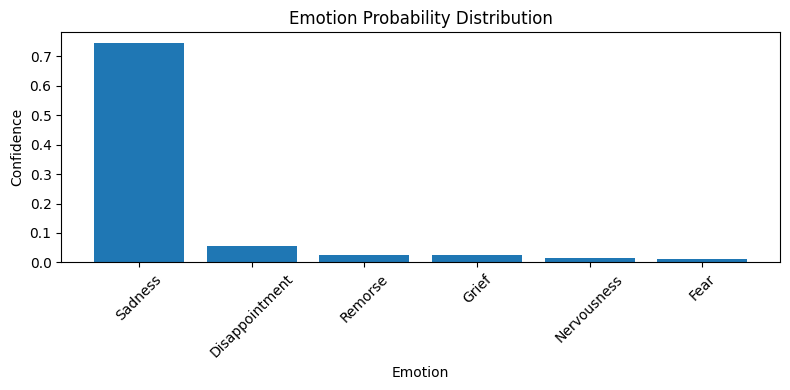

--------------------------------------------------

Input: I'm proud and excited

Detected Emotion: Pride 🏆
Confidence: 91%

Explanation:
The text reflects a feeling of accomplishment or self-respect.

Other Detected Emotions:

Emotion Probability Breakdown:
Pride           91%
Joy             13%
Admiration      9%
Relief          9%
Excitement      5%
Approval        4%


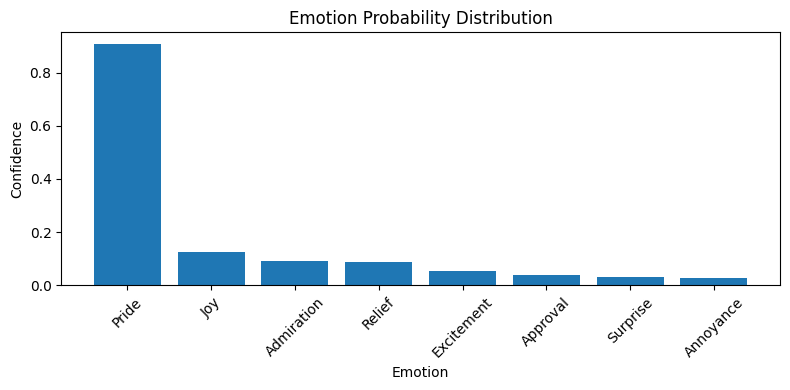

--------------------------------------------------

Input: I love you but I'm scared

Detected Emotion: Fear 😨
Confidence: 69%

Explanation:
The text shows anxiety, worry, or fear.

Other Detected Emotions:

Emotion Probability Breakdown:
Fear            69%
Nervousness     5%
Love            2%
Desire          2%
Sadness         1%
Annoyance       1%


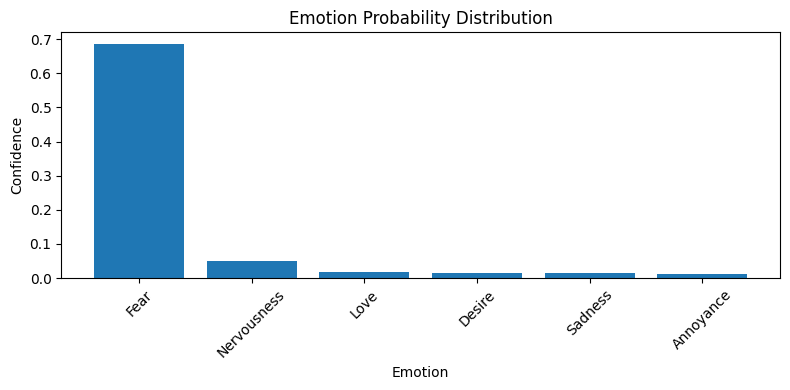

--------------------------------------------------

Input: This is hilarious

Detected Emotion: Amusement 😂
Confidence: 49%

Explanation:
The text reflects that something is funny or entertaining.

Other Detected Emotions:

Emotion Probability Breakdown:
Amusement       49%
Joy             3%
Excitement      1%
Surprise        1%


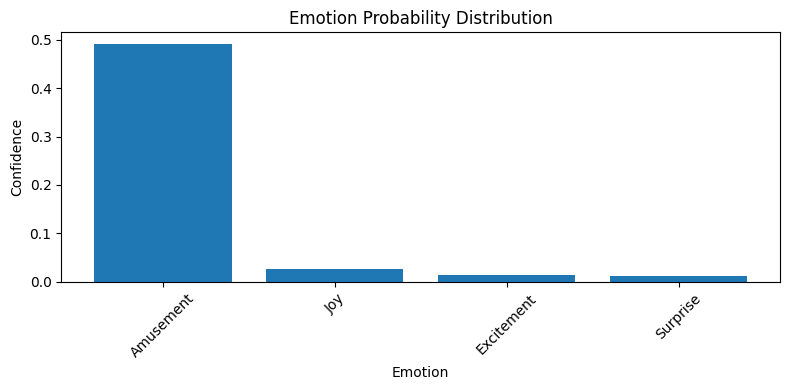

--------------------------------------------------

Input: Everything goes wrong

Detected Emotion: Disappointment 😞
Confidence: 7%

Explanation:
The text reflects dissatisfaction or unmet expectations.

Emotion Probability Breakdown:
Disappointment  7%
Sadness         3%
Disapproval     3%
Annoyance       3%
Realization     3%
Neutral         1%


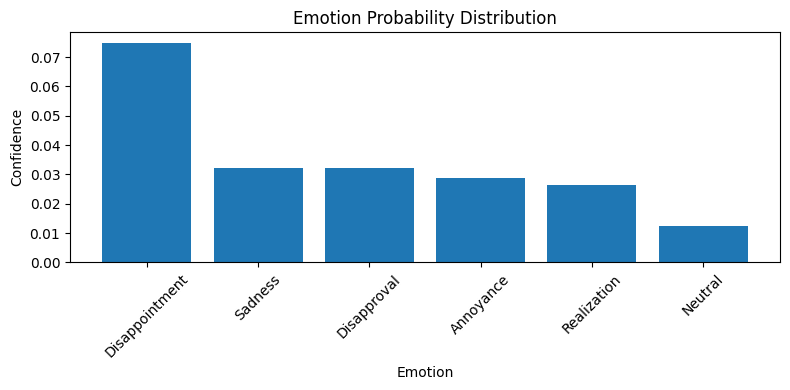

--------------------------------------------------


In [ ]:
tests = [
    "I'm broken and sad",
    "I'm proud and excited",
    "I love you but I'm scared",
    "This is hilarious",
    "Everything goes wrong"
]

for t in tests:

    print("\nInput:", t)

    result = predict_emotions(t)

    display_result(result)

    plot_emotions(result)

    print("-" * 50)